In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import sqlite3
import pandas as pd
import random
from datetime import datetime, timedelta

# 1. Connect to a virtual database
conn = sqlite3.connect('ecommerce_analytics.db')
cursor = conn.cursor()

# 2. Clear old data if it exists so we don't get UNIQUE errors
cursor.execute("DROP TABLE IF EXISTS customers;")
cursor.execute("DROP TABLE IF EXISTS sales;")

# 3. Create Tables Fresh
cursor.execute('''
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    signup_date TEXT,
    country TEXT
)''')

cursor.execute('''
CREATE TABLE sales (
    sale_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    purchase_date TEXT,
    amount_spent REAL,
    category TEXT
)''')

# 4. Generate Mock Data
countries = ['USA', 'India', 'UK', 'Canada', 'Germany']
categories = ['Electronics', 'Clothing', 'Home', 'Books']

# Insert 100 fake customers
for i in range(1, 101):
    signup = (datetime(2025, 1, 1) + timedelta(days=random.randint(0, 180))).strftime('%Y-%m-%d')
    cursor.execute("INSERT INTO customers VALUES (?, ?, ?)", (i, signup, random.choice(countries)))

# Insert 500 fake purchases
for j in range(1, 501):
    cust_id = random.randint(1, 100)
    p_date = (datetime(2025, 7, 1) + timedelta(days=random.randint(0, 180))).strftime('%Y-%m-%d')
    amount = round(random.uniform(10.0, 500.0), 2)
    cursor.execute("INSERT INTO sales VALUES (?, ?, ?, ?, ?)", (j, cust_id, p_date, amount, random.choice(categories)))

conn.commit()
print(" Success! Your virtual SQL database is fresh and ready.")

 Success! Your virtual SQL database is fresh and ready.


In [5]:
query_top_spenders="""
                   SELECT customer_id,
                   COUNT(sale_id) AS total_money_spent
                   FROM sales
                   GROUP BY customer_id
                   ORDER BY total_money_spent DESC
                   LIMIT 10;
                   """
print("TOP 10 HIGHEST SPENDING CUSTOMERS")
df_top=pd.read_sql_query(query_top_spenders,conn)
print(df_top)
print("\n"+"="*40+"\n")

query_countries="""
                SELECT c.country,
                SUM(s.amount_spent)AS total_revenue,
                COUNT(s.sale_id)AS total_sales
                FROM sales s
                JOIN customers c ON s.customer_id=c.customer_id
                GROUP BY c.country
                ORDER BY total_revenue DESC;
                """
print("REVENUE BY COUNTRY")
df_countries=pd.read_sql_query(query_countries,conn)
print(df_countries)



TOP 10 HIGHEST SPENDING CUSTOMERS
   customer_id  total_money_spent
0           38                 11
1           88                 10
2           31                 10
3           11                 10
4          100                  9
5           96                  9
6           79                  9
7           99                  8
8           91                  8
9           66                  8


REVENUE BY COUNTRY
   country  total_revenue  total_sales
0      USA       32258.87          120
1   Canada       31738.11          118
2    India       23608.36           99
3       UK       21915.87           81
4  Germany       21250.42           82


ValueError: weight='bold,pad=15' is invalid

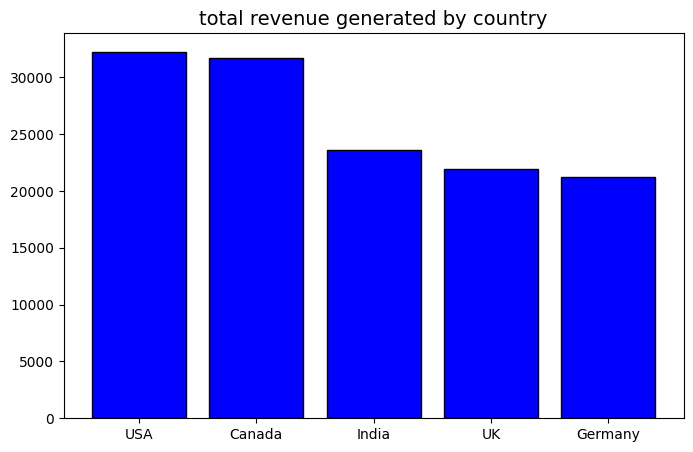

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df_countries['country'],df_countries['total_revenue'],color='blue',edgecolor='black')

plt.title('total revenue generated by country',fontsize=14,fontweight='bold,pad=15')
plt.xlabel('country name ',fontsize=12)
plt.ylabel('total revenue($)',fontsize-12)

plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.show

In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np


X = np.array([[1], [2], [3], [5], [8], [12]])
y = np.array([45, 95, 140, 260, 410, 590])


model = LinearRegression()
model.fit(X, y)


new_customer_orders = np.array([[6]])
predicted_spending = model.predict(new_customer_orders)

print("--- MACHINE LEARNING PREDICTION ENGINE ---")
print(f"If a new customer makes 6 purchases in month one...")
print(f"The AI predicts they will spend: ${predicted_spending[0]:.2f} by the end of the year!")

--- MACHINE LEARNING PREDICTION ENGINE ---
If a new customer makes 6 purchases in month one...
The AI predicts they will spend: $298.49 by the end of the year!
